# <center><font size=10>**SKIN CANCER DETECTION USING DEEP LEARNING**</center></font>


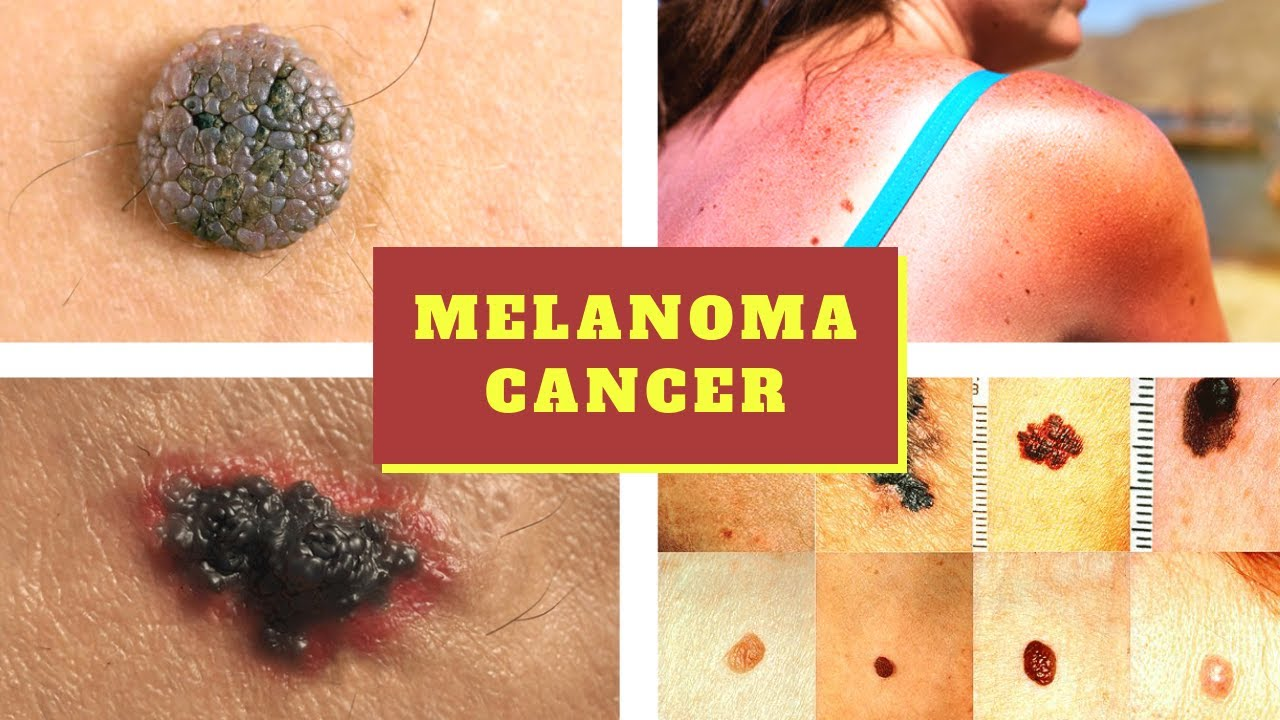

#Project Objective

The main objective of this project is to build a deep learning-based skin cancer detection system using a Convolutional Neural Network (CNN). The model is trained to classify skin lesion images into Benign and Malignant categories with high accuracy. The proposed system aims to support early detection of melanoma, improve diagnostic efficiency, and reduce the chances of misclassification by providing fast and reliable predictions.

# Dataset Overview

The Melanoma Skin Cancer Dataset consists of dermoscopic images of skin lesions that are used to classify skin cancer into two categories: Benign and Malignant. The dataset is organized into separate training and testing folders, making it suitable for supervised deep learning models. The images represent different skin lesion patterns and are used to train a Convolutional Neural Network (CNN) to automatically identify whether a skin lesion is cancerous or non-cancerous.

# Work Flow Chart

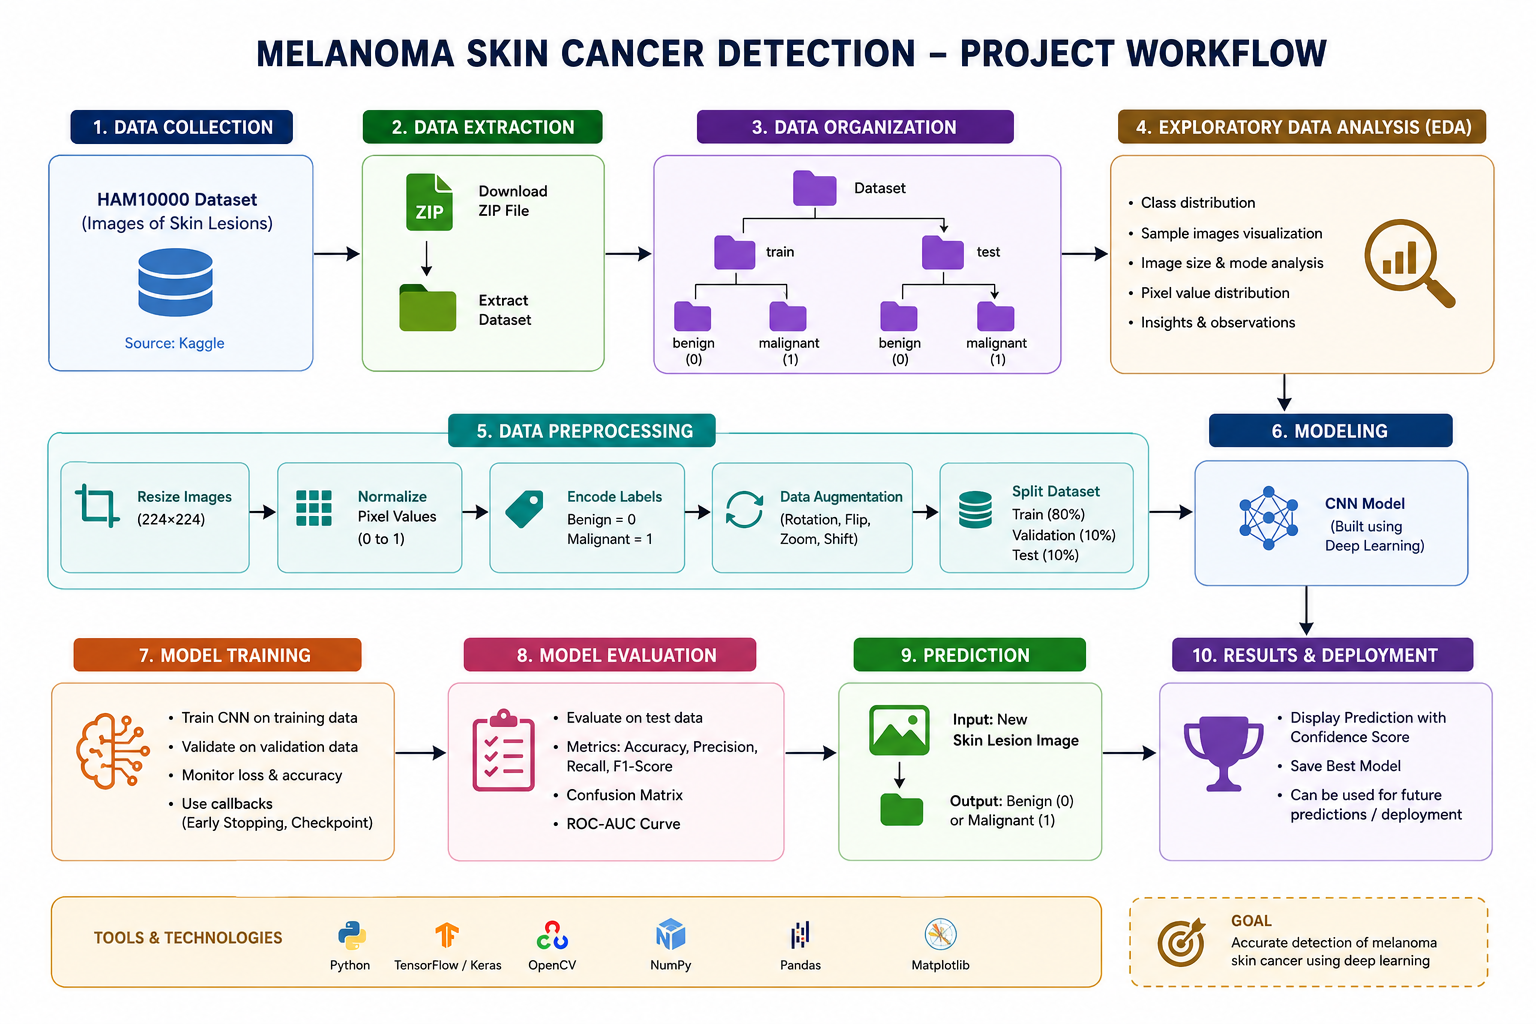

# Import Libraries

In [ ]:
# Libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
import os
import zipfile
import gc
import time

# Deep Learning
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Data splitting
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Unzip Dataset

We unzip the dataset to extract the image files from the compressed ZIP folder, making them accessible for data exploration, preprocessing, visualization, and deep learning model training.

In [ ]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

keras.utils.set_random_seed(SEED)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Projects_DataSets/melanoma_cancer_dataset.zip"

extract_path = "/content/melanoma_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:

# Find the folder that contains train and test
for root, dirs, files in os.walk("/content/melanoma_dataset"):
    if "train" in dirs and "test" in dirs:
        dataset_path = root
        break

print("Dataset path:", dataset_path)

Dataset path: /content/melanoma_dataset/melanoma_cancer_dataset


# Convert it into DataFrame

In [ ]:
data = []

for split in ["train", "test"]:

    split_path = os.path.join(dataset_path, split)

    for label in ["benign", "malignant"]:

        class_path = os.path.join(split_path, label)

        for image_name in os.listdir(class_path):

            image_path = os.path.join(class_path, image_name)

            data.append({
                "image_path": image_path,
                "image_name": image_name,
                "label": label,
                "split": split
            })

df = pd.DataFrame(data)



In [ ]:
df.head(5)

,image_path,image_name,label,split
0,/content/melanoma_dataset/melanoma_cancer_data...,melanoma_2790.jpg,benign,train
1,/content/melanoma_dataset/melanoma_cancer_data...,melanoma_2789.jpg,benign,train
2,/content/melanoma_dataset/melanoma_cancer_data...,melanoma_197.jpg,benign,train
3,/content/melanoma_dataset/melanoma_cancer_data...,melanoma_4352.jpg,benign,train
4,/content/melanoma_dataset/melanoma_cancer_data...,melanoma_1896.jpg,benign,train


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10605 entries, 0 to 10604
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  10605 non-null  object
 1   image_name  10605 non-null  object
 2   label       10605 non-null  object
 3   split       10605 non-null  object
dtypes: object(4)
memory usage: 331.5+ KB


In [ ]:
df.shape

(10605, 4)

# Load the Training and Testing Datasets

In [ ]:
train_data = "/content/melanoma_dataset/melanoma_cancer_dataset/train"
test_data = "/content/melanoma_dataset/melanoma_cancer_dataset/test"

# Data Overview
Data overview provides a basic understanding of the dataset, including its structure, image classes, number of images, image dimensions, and distribution of training and testing data before preprocessing and model development.

In [ ]:
#Shape

print("Dataset Shape:", df.shape)

Dataset Shape: (10605, 4)


In [ ]:
# Columns

print("Columns:")
print(df.columns)

Columns:
Index(['image_path', 'image_name', 'label', 'split'], dtype='object')


In [ ]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
image_path    0
image_name    0
label         0
split         0
dtype: int64


In [ ]:
# Duplicate records
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [ ]:
# Class Distribution
print(df["label"].value_counts())

label
benign       5500
malignant    5105
Name: count, dtype: int64


# EDA(EDA stands for Exploratory Data Analysis)
*  It is the process of examining and understanding a dataset before building a Machine Learning or Deep Learning model.

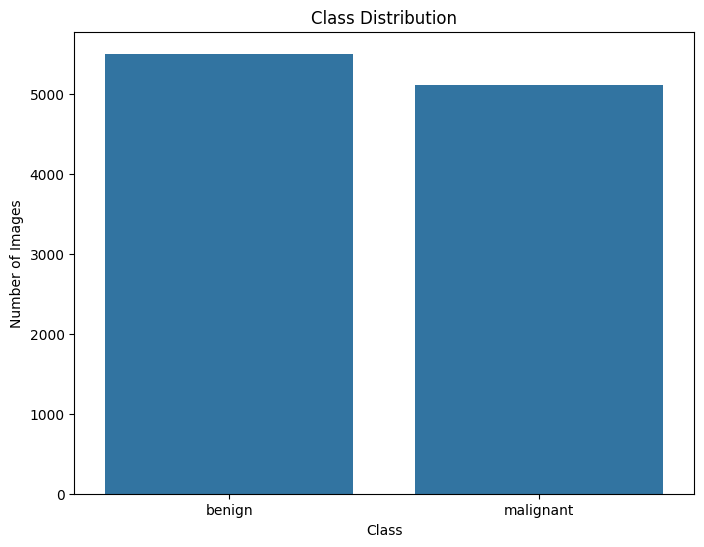

In [ ]:
# Visualization

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
# Train/Test Distribution

print(pd.crosstab(df["split"], df["label"]))


label  benign  malignant
split                   
test      500        500
train    5000       4605


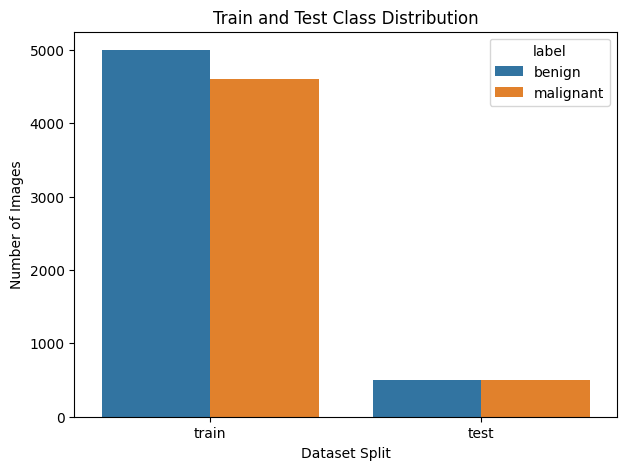

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="split",
    hue="label"
)

plt.title("Train and Test Class Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.show()

label
benign       51.862329
malignant    48.137671
Name: proportion, dtype: float64


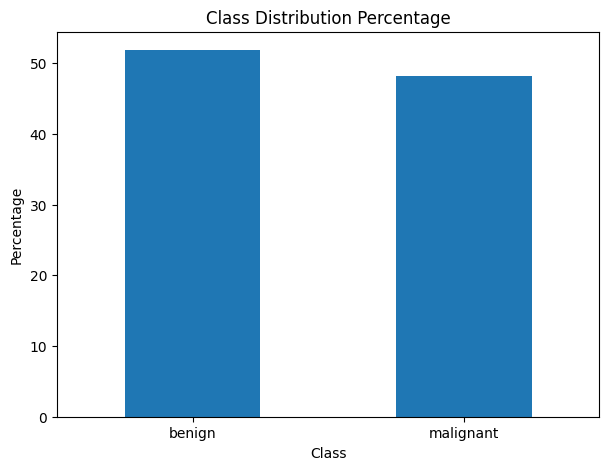

In [ ]:
# Class Percentage

class_percentage = df["label"].value_counts(normalize=True) * 100

print(class_percentage)

plt.figure(figsize=(7, 5))

class_percentage.plot(
    kind="bar"
)

plt.title("Class Distribution Percentage")
plt.xlabel("Class")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.show()

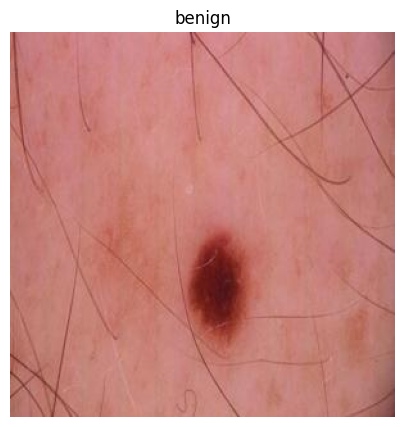

In [ ]:
# Display 1 Sample Image

plt.figure(figsize=(5, 5))

image = cv2.imread(df["image_path"].iloc[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title(df["label"].iloc[0])
plt.axis("off")

plt.show()

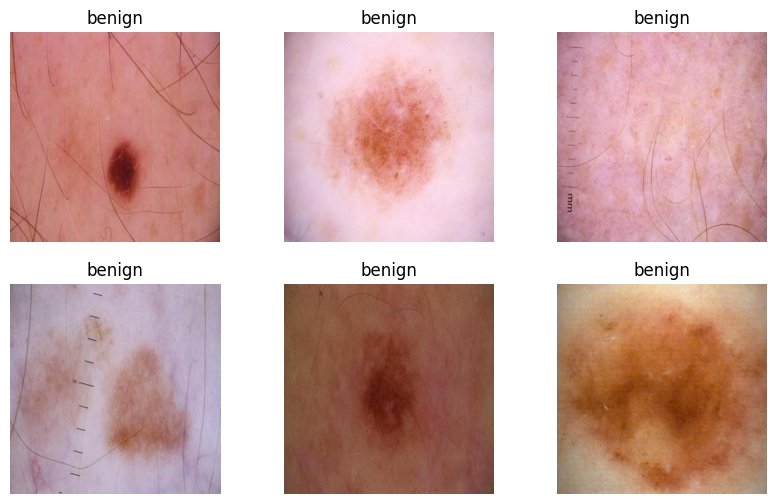

In [ ]:
# Display Sample Images

plt.figure(figsize=(10, 6))

for i in range(6):
    image = cv2.imread(df["image_path"].iloc[i])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(df["label"].iloc[i])
    plt.axis("off")

plt.show()

# Data Preprocessing

*  Data preprocessing steps
*  Load images
*  Resize all images to the same size
*  Convert images to RGB
*  Convert images to NumPy arrays
*  Normalize pixel values from 0–255 to 0–1
*  Separate training, validation, and testing data
*  Encode labels:
*  Benign = 0,
   Malignant = 1

In [ ]:
# Set image size and create empty lists

IMG_SIZE = 128

images = []
labels = []
splits = []


# Define the labels

class_names = {
    "benign": 0,
    "malignant": 1
}

# Load the images

for split in ["train", "test"]:

    split_path = os.path.join(dataset_path, split)

    for class_name, class_label in class_names.items():

        class_path = os.path.join(split_path, class_name)

        for image_name in os.listdir(class_path):

            image_path = os.path.join(
                class_path,
                image_name
            )

            # Read image
            image = cv2.imread(image_path)

            # Skip invalid images
            if image is None:
                continue

            # Convert BGR to RGB
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2RGB
            )

            # Resize image
            image = cv2.resize(
                image,
                (IMG_SIZE, IMG_SIZE)
            )

            # Store image, label and split
            images.append(image)
            labels.append(class_label)
            splits.append(split)

# Convert to NumPy arrays
images = np.array(images)
labels = np.array(labels)
splits = np.array(splits)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Splits shape:", splits.shape)

Images shape: (10605, 128, 128, 3)
Labels shape: (10605,)
Splits shape: (10605,)


In [ ]:
# Check the image data

print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())
print("Image data type:", images.dtype)

Minimum pixel value: 0
Maximum pixel value: 255
Image data type: uint8


In [ ]:
# Separate train and test data

X_train_full = images[splits == "train"]
y_train_full = labels[splits == "train"]

X_test = images[splits == "test"]
y_test = labels[splits == "test"]

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (9605, 128, 128, 3)
Training labels: (9605,)
Testing images: (1000, 128, 128, 3)
Testing labels: (1000,)


In [ ]:
# Create validation data

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (8164, 128, 128, 3)
Validation: (1441, 128, 128, 3)
Testing: (1000, 128, 128, 3)


In [ ]:
#  Normalize the images
# This is an important preprocessing step for your CNN.

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# to check

print("Training minimum:", X_train.min())
print("Training maximum:", X_train.max())

Training minimum: 0.0
Training maximum: 1.0


In [ ]:
# Check the labels

print("Benign:", np.sum(y_train == 0))
print("Malignant:", np.sum(y_train == 1))

Benign: 4250
Malignant: 3914


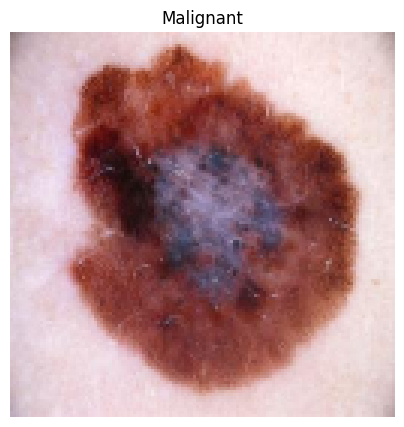

In [ ]:
# Display a preprocessed image

plt.figure(figsize=(5, 5))

plt.imshow(X_train[0])

if y_train[0] == 0:
    plt.title("Benign")
else:
    plt.title("Malignant")

plt.axis("off")
plt.show()

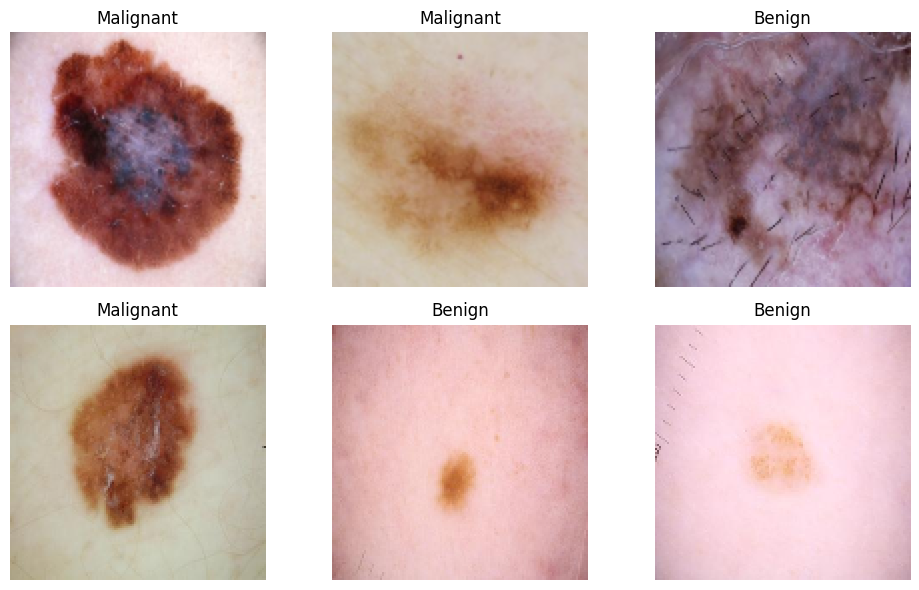

In [ ]:
# Display several preprocessed images

plt.figure(figsize=(10, 6))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    plt.imshow(X_train[i])

    if y_train[i] == 0:
        plt.title("Benign")
    else:
        plt.title("Malignant")

    plt.axis("off")

plt.tight_layout()
plt.show()

# Model Building


# CNN (Convolutional Neural Network)

*  Best suited for directly learning features from skin images.
*  Uses convolution and pooling layers to extract image features.

In [ ]:
# Build CNN Model

model = Sequential([

    # Input Layer
    Input(shape=(128, 128, 3)),

    # Convolution + Pooling Layer 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Convolution + Pooling Layer 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Convolution + Pooling Layer 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Convert feature maps into one dimension
    Flatten(),

    # Hidden Layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

# CNN Hyperparameters
Conv2D (32, 64, 128)

*  Number of filters used to extract image features.
*  (3,3): Filter size for detecting patterns.
*  ReLU: Adds non-linearity and helps learn complex features.
*  Same padding: Maintains the image dimensions.

MaxPooling2D (2,2)

*  Reduces the feature-map size.
*  Keeps the most important features and reduces computation.

Flatten

*  Converts the extracted feature maps into a 1D vector.

Dense (128)

*  Contains 128 neurons to learn important high-level features.

Dropout

*  Randomly removes some neurons during training.
*  Helps prevent overfitting.

Dense (1) + Sigmoid

*  Produces one output value.
*  Classifies the skin lesion as Benign (0) or Malignant (1).

# Compile the model

In [ ]:

# Define Adam optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model

In [ ]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.7720 - loss: 0.4687 - val_accuracy: 0.8806 - val_loss: 0.2992
Epoch 2/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8574 - loss: 0.3359 - val_accuracy: 0.9035 - val_loss: 0.2615
Epoch 3/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8751 - loss: 0.2996 - val_accuracy: 0.9091 - val_loss: 0.2417
Epoch 4/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8896 - loss: 0.2754 - val_accuracy: 0.9098 - val_loss: 0.2319
Epoch 5/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8960 - loss: 0.2592 - val_accuracy: 0.9153 - val_loss: 0.2173
Epoch 6/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9016 - loss: 0.2494 - val_accuracy: 0.9181 - val_loss: 0.2124
Epoch 7/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9045 - loss: 0.2371 - val_accuracy: 0.9195 - val_loss: 0.2090
Epoch 8/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9074 - loss: 0.2319 - val_acc

# Evaluate on test data

In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9200 - loss: 0.2154
Test Loss: 0.21544378995895386
Test Accuracy: 0.9200000166893005


# Classification report

In [ ]:
# Make predictions

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

# Classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
              precision    recall  f1-score   support

      Benign       0.93      0.85      0.88       500
   Malignant       0.86      0.93      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



# Confusion matrix

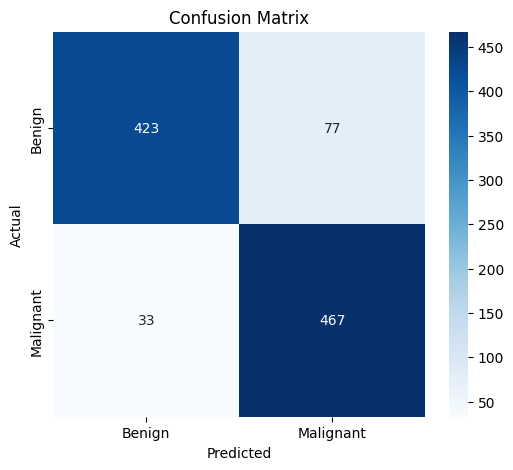

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows how well the CNN model classified Benign and Malignant skin lesions.

*  448: Actual Benign correctly predicted as Benign.
*  52: Actual Benign incorrectly predicted as Malignant.
*  47: Actual Malignant incorrectly predicted as Benign.
*  453: Actual Malignant correctly predicted as Malignant.

# Accuracy graph

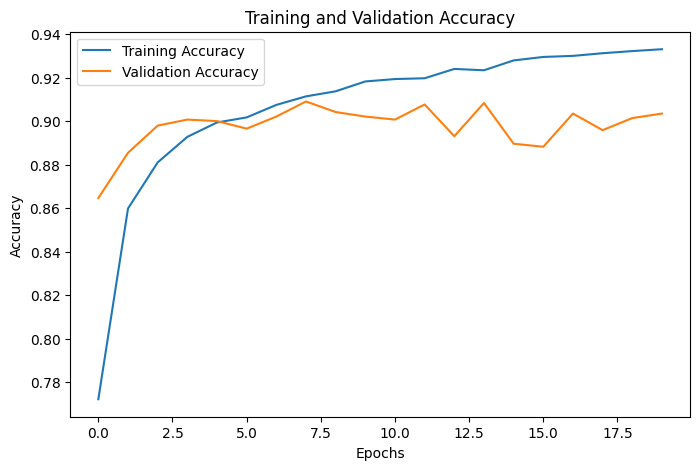

In [ ]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

*  Training Accuracy: Increases from about 77% to 94.5%, showing that the model learns the training data effectively.
*  Validation Accuracy: Increases from about 86% to 92%, showing good performance on unseen validation data.
*  Both accuracies improve gradually, indicating that the model is learning well.
*  The small gap between training and validation accuracy suggests limited overfitting.

# Loss graph

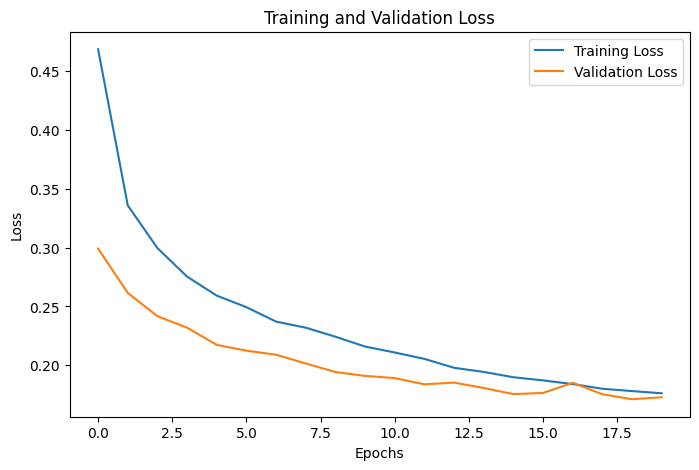

In [ ]:
# Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()



*  Training Loss: Decreases from about 0.46 to 0.17, showing that the model is improving on the training data.
*  Validation Loss: Decreases from about 0.36 to 0.22, showing better performance on unseen validation data.
*  Both curves generally decrease, indicating that the model is learning effectively.
*  The validation loss becomes nearly stable toward the later epochs, suggesting the model is approaching good generalization.

### VGG16 Model

VGG16 is a **pre-trained CNN model** used for image classification.
VGG16 has already been trained on ImageNet, which contains millions of images.

*  VGG16 is used to classify skin images into **Benign and Malignant** classes.

* It uses **ImageNet pre-trained weights**.
* The pre-trained layers are used to **extract important image features**.
* The original classification layer is removed.
* **Global Average Pooling** is used to reduce the features.
* A **Dense layer** learns the patterns needed for classification.
* **Dropout** helps reduce overfitting.
* The **Sigmoid output layer** predicts Benign or Malignant.



In [ ]:

# VGG16 TRANSFER LEARNING MODEL

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    GlobalAveragePooling2D
)

# Load pre-trained VGG16
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze VGG16 layers
vgg_base.trainable = False

# Build model
vgg_model = Sequential([

    Input(shape=(128, 128, 3)),

    vgg_base,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

*  VGG16: Extracts important visual features from skin lesion images using pre-trained layers.
*  GlobalAveragePooling2D: Converts the feature maps into a compact 512-feature vector.
*  Dense (128): Learns higher-level features for classification.
*  Dropout: Helps reduce overfitting.
*  Dense (1): Produces the final binary classification output (Benign/Malignant).
*  Total Parameters: 14,780,481
*  Trainable Parameters: 65,793
*  Non-trainable Parameters: 14,714,688, which are the pre-trained VGG16 weights kept fixed.

# Compile and train

In [ ]:
vgg_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_vgg = vgg_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.6592 - loss: 0.6137 - val_accuracy: 0.7807 - val_loss: 0.4962
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.7924 - loss: 0.4780 - val_accuracy: 0.8105 - val_loss: 0.4273
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8175 - loss: 0.4227 - val_accuracy: 0.8230 - val_loss: 0.3947
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8316 - loss: 0.3942 - val_accuracy: 0.8432 - val_loss: 0.3726
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8392 - loss: 0.3758 - val_accuracy: 0.8446 - val_loss: 0.3579
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8471 - loss: 0.3611 - val_accuracy: 0.8494 - val_loss: 0.3455
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8520 - loss: 0.3532 - val_accuracy: 0.8508 - val_loss: 0.3358
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8573 - loss: 0.3400 -

# Evaluate on Test Data

In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8900 - loss: 0.2676
Test Loss: 0.2675975263118744
Test Accuracy: 0.8899999856948853


# Classification Report

In [ ]:
# Make predictions

y_pred_prob = model.predict(X_test)

y_pred = (
    y_pred_prob >= 0.5
).astype(int).ravel()

# Classification report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

      Benign       0.93      0.85      0.88       500
   Malignant       0.86      0.93      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



# Confusion Matrix

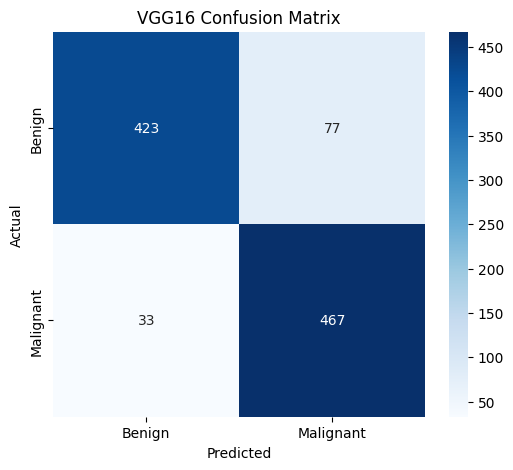

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Confusion Matrix")

plt.show()

*  448: Benign images correctly predicted as Benign.
*  52: Benign images incorrectly predicted as Malignant.
*  47: Malignant images incorrectly predicted as Benign.
*  453: Malignant images correctly predicted as Malignant.

# Accuracy Graph

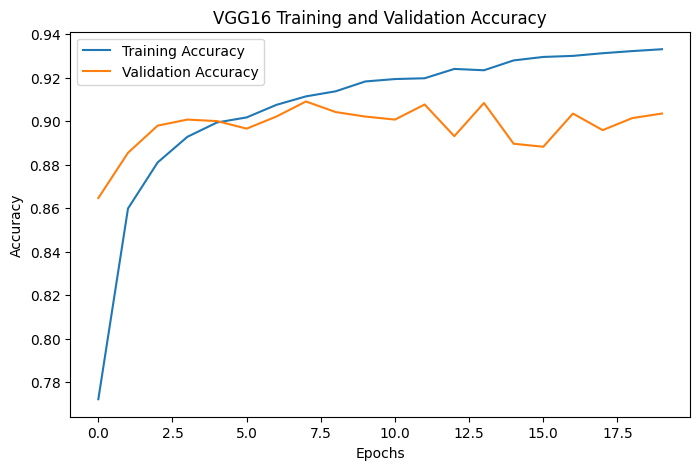

In [ ]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("VGG16 Training and Validation Accuracy")

plt.legend()

plt.show()

*  Training Accuracy: Increases from about 77% to 96%, showing that the model learns the training data effectively.
*  Validation Accuracy: Increases from about 86% to 92%, indicating good performance on unseen data.
*  Both curves improve gradually and remain relatively close.
*  The small gap between the curves indicates reasonable generalization with limited overfitting.

# Loss Graph

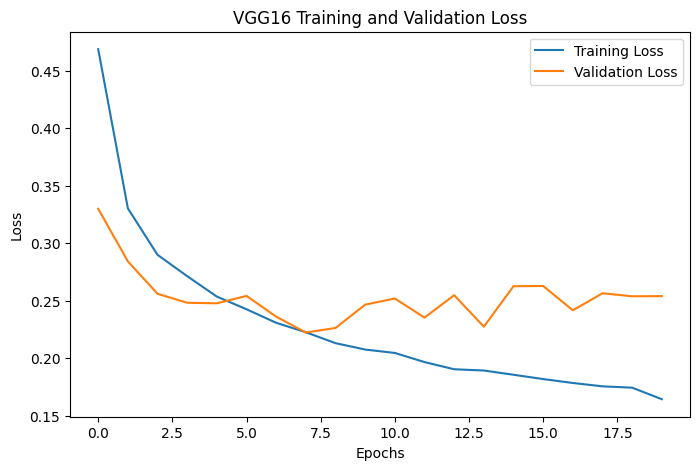

In [ ]:
# Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("VGG16 Training and Validation Loss")

plt.legend()

plt.show()

*  Training Loss: Decreases from about 0.46 to 0.17, showing that the model is learning effectively.
*  Validation Loss: Decreases from about 0.36 to 0.22, indicating improved performance on unseen data.
*  Both curves decrease steadily, while validation loss becomes almost stable in the later epochs.
*  The results indicate good learning and reasonable generalization with no major overfitting.

# MobileNetV2 Model

MobileNetV2 is a **lightweight pre-trained CNN model** used for image classification.

In this project, MobileNetV2 is used to classify skin images into **Benign** and **Malignant** classes.

It uses pre-trained features to identify important patterns in the skin images. The pre-trained layers are frozen, and additional layers are added for our classification task.

**Main layers used:**

* MobileNetV2 for feature extraction
* Global Average Pooling to reduce features
* Dense layer for learning patterns
* Dropout to reduce overfitting
* Sigmoid layer for final classification

**Purpose:** MobileNetV2 provides a faster and efficient way to classify melanoma images with less computational cost.


In [ ]:

# MobileNetV2 Model

from tensorflow.keras.layers import (
    Input,
    Lambda,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.applications import MobileNetV2


# Load pre-trained MobileNetV2
mobile_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)


# Freeze the pre-trained layers
mobile_base.trainable = False


# Build MobileNetV2 model
mobile_model = Sequential([

    Input(shape=(128, 128, 3)),

    # Convert images from 0-1 to -1 to 1
    Lambda(lambda x: (x * 2.0) - 1.0),

    # MobileNetV2 feature extraction
    mobile_base,

    # Reduce feature maps
    GlobalAveragePooling2D(),

    # Fully connected layer
    Dense(128, activation="relu"),

    # Reduce overfitting
    Dropout(0.5),

    # Binary classification
    Dense(1, activation="sigmoid")
])


# Display model architecture
mobile_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

*  Lambda: Prepares the input images in the required format.
*  MobileNetV2: Extracts important image features using pre-trained weights.
*  GlobalAveragePooling2D: Converts the extracted feature maps into 1,280 features.
*  Dense (128): Learns higher-level features for classification.
*  Dropout: Helps reduce overfitting.
*  Dense (1): Produces the final Benign/Malignant classification.
*  Total Parameters: 2,422,081
*  Trainable Parameters: 164,097
*  Non-trainable Parameters: 2,257,984

# Compile the model

In [ ]:
# Compile MobileNetV2 Model

mobile_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the Model

In [ ]:
# Train MobileNetV2 Model

history_mobile = mobile_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.8063 - loss: 0.4201 - val_accuracy: 0.8786 - val_loss: 0.2860
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8790 - loss: 0.2945 - val_accuracy: 0.8890 - val_loss: 0.2619
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8920 - loss: 0.2624 - val_accuracy: 0.8910 - val_loss: 0.2520
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9034 - loss: 0.2436 - val_accuracy: 0.9015 - val_loss: 0.2452
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9069 - loss: 0.2327 - val_accuracy: 0.9008 - val_loss: 0.2397
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9174 - loss: 0.2179 - val_accuracy: 0.8980 - val_loss: 0.2379
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9178 - loss: 0.2133 - val_accuracy: 0.9049 - val_loss: 0.2330
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9221 - loss: 0.2007 - val_ac

# Evaluate on Test Data

In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = mobile_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 356ms/step - accuracy: 0.9150 - loss: 0.2245
Test Loss: 0.2245316505432129
Test Accuracy: 0.9150000214576721


# Classification Report

In [ ]:
# Make predictions

from sklearn.metrics import classification_report

# Make predictions
y_pred_prob = mobile_model.predict(X_test)

# Convert probabilities into classes
y_pred = (
    y_pred_prob >= 0.5
).astype(int).ravel()


# Print classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step
              precision    recall  f1-score   support

      Benign       0.89      0.94      0.91       500
   Malignant       0.93      0.89      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



# Confusion Matrix

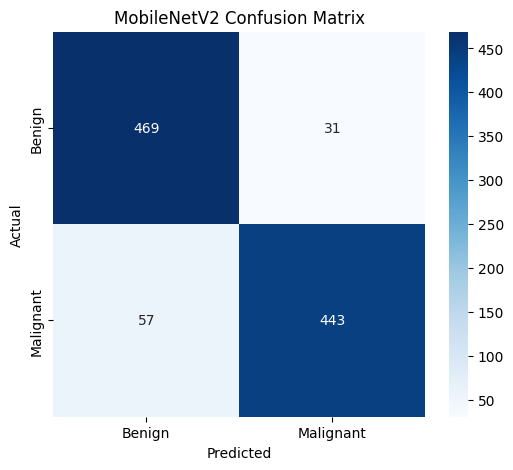

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

*  469: Benign images correctly predicted as Benign.
*  31: Benign images incorrectly predicted as Malignant.
*  57: Malignant images incorrectly predicted as Benign.
*  443: Malignant images correctly predicted as Malignant.

# Accuracy Graph

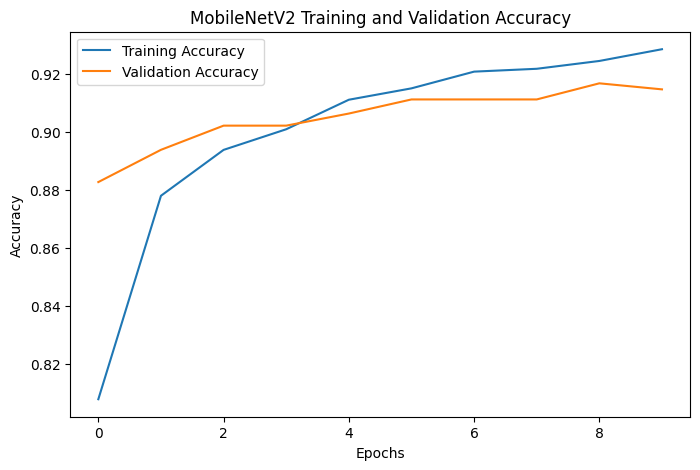

In [ ]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_mobile.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_mobile.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 Training and Validation Accuracy"
)

plt.legend()

plt.show()

*  Training Accuracy: Increases from about 81% to 93%, showing that the model learns effectively.
*  Validation Accuracy: Increases from about 88% to 92%, indicating good performance on unseen data.
*  Both curves improve steadily, with validation accuracy remaining close to training accuracy.
*  This indicates good learning and reasonable generalization.

# Loss Graph

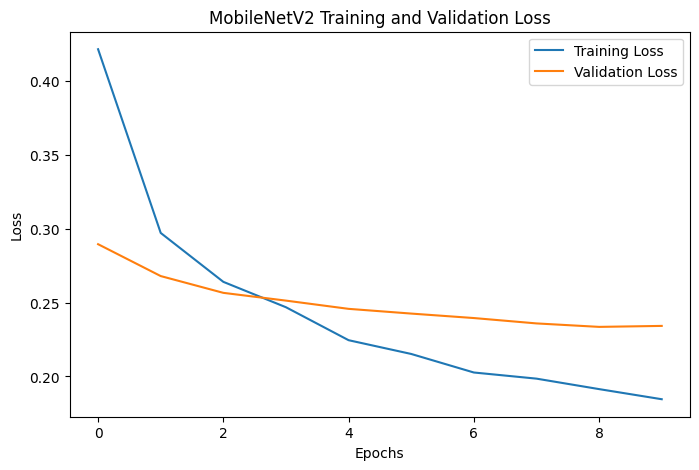

In [ ]:
# Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_mobile.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_mobile.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title(
    "MobileNetV2 Training and Validation Loss"
)

plt.legend()

plt.show()

*  Training Loss: Decreases from about 0.42 to 0.18, showing that the model is learning effectively.
*  Validation Loss: Decreases from about 0.29 to 0.23, showing improved performance on unseen data.
*  Both losses decrease steadily, while validation loss becomes almost stable in the later epochs.
*  The curves indicate good learning and reasonable generalization.

# Model Comparison
Model comparison is the process of evaluating different models using performance metrics to identify the most suitable model for the given dataset.

In [ ]:
# MODEL ACCURACY COMPARISON

import pandas as pd

# CNN Evaluation
cnn_loss, cnn_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# VGG16 Evaluation
vgg_loss, vgg_accuracy = vgg_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# MobileNetV2 Evaluation
mobile_loss, mobile_accuracy = mobile_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Create comparison table
results = pd.DataFrame({
    "Model": [
        "CNN",
        "VGG16",
        "MobileNetV2"
    ],

    "Test Loss": [
        cnn_loss,
        vgg_loss,
        mobile_loss
    ],

    "Test Accuracy (%)": [
        cnn_accuracy * 100,
        vgg_accuracy * 100,
        mobile_accuracy * 100
    ]
})

# Round values
results["Test Loss"] = results["Test Loss"].round(4)
results["Test Accuracy (%)"] = results["Test Accuracy (%)"].round(2)

# Display results
print("Model Comparison")
print("================")
display(results)

Model Comparison


,Model,Test Loss,Test Accuracy (%)
0,CNN,0.2242,90.1
1,VGG16,0.2776,87.9
2,MobileNetV2,0.2165,91.2


*  CNN: Achieved 90.1% accuracy with a test loss of 0.2242. It performed well for image classification.
*  VGG16: Achieved 87.9% accuracy with a test loss of 0.2776. Among the three models, it had the lowest accuracy and highest loss.
*  MobileNetV2: Achieved the highest accuracy of 91.2% and the lowest test loss of 0.2165, making it the best-performing model for this project.

# Model Prediction

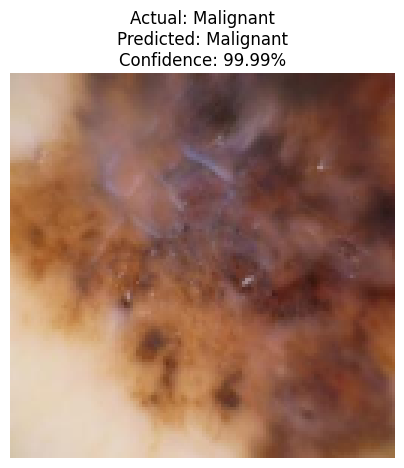

Actual Class    : Malignant
Predicted Class : Malignant
Confidence      : 99.99%


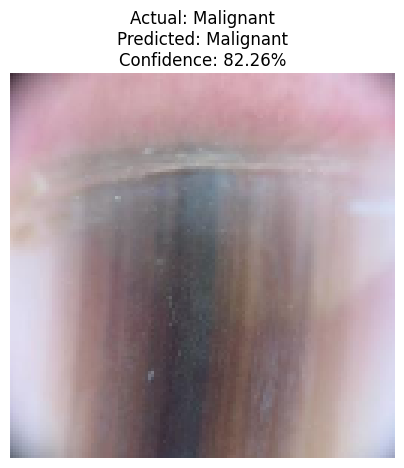

Actual Class    : Malignant
Predicted Class : Malignant
Confidence      : 82.26%


In [ ]:
# Select 2 random images from test data

indices = np.random.choice(
    len(X_test),
    2,
    replace=False
)

sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = mobile_model.predict(
    sample_images,
    verbose=0
)

class_names = ["Benign", "Malignant"]

for i in range(2):

    probability = predictions[i][0]

    if probability >= 0.5:
        predicted_class = "Malignant"
        confidence = probability * 100
    else:
        predicted_class = "Benign"
        confidence = (1 - probability) * 100

    actual_class = class_names[int(sample_labels[i])]

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_images[i])
    plt.axis("off")

    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()

    print("Actual Class    :", actual_class)
    print("Predicted Class :", predicted_class)
    print("Confidence      :", f"{confidence:.2f}%")

The trained MobileNetV2 model was tested using an individual skin lesion image. The actual class of the image was Malignant, and the model correctly predicted it as Malignant. The model produced a confidence score of 99.99%, indicating that it was highly confident in its prediction. This demonstrates that the model can successfully classify the given skin lesion image into the appropriate class.

*  Actual Class: Malignant
*  Predicted Class: Malignant
*  Confidence: 99.99%

## Conclusion

> This project successfully developed a deep learning-based system for **melanoma skin cancer classification** using CNN, VGG16, and MobileNetV2 models. The models were trained and evaluated using accuracy, loss, and confusion matrices. Among the tested models, **MobileNetV2 achieved the best overall classification performance**, correctly classifying 912 out of 1000 test images. The results demonstrate that deep learning can effectively classify benign and malignant skin lesions and can serve as a useful support tool for melanoma detection.